In [1]:
"""
This notebook is designed to help you practice and master advanced data cleaning, transformation, and predictive analytics techniques using pandas.
"""


'\nThis notebook is designed to help you practice and master advanced data cleaning, transformation, and predictive analytics techniques using pandas.\n'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [4]:
df2 = pd.read_excel(r"C:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\data\raw_ar_data.xlsx")

In [5]:
df = df2.copy()

In [6]:
df.columns

Index(['ACCOUNT NUMBER', 'TYPE', 'FINAL READING', 'INITIAL READING',
       'MULTIPLIER', 'CONSUMPTION', 'TARIFF', 'RATE',
       'PREVIOUS CLOSING BALANCE', 'PREVIOUS PAYMENTS', 'OPENING BALANCE',
       'ADJUSTMENTS TOTAL', 'BILL AMOUNT', 'CLOSING BALANCE', 'PERIOD',
       'BILL STYLE', 'FEEDER'],
      dtype='object')

In [7]:
df.head()


,ACCOUNT NUMBER,TYPE,FINAL READING,INITIAL READING,MULTIPLIER,CONSUMPTION,TARIFF,RATE,PREVIOUS CLOSING BALANCE,PREVIOUS PAYMENTS,OPENING BALANCE,ADJUSTMENTS TOTAL,BILL AMOUNT,CLOSING BALANCE,PERIOD,BILL STYLE,FEEDER
0,KN659082472,MD,3118.0,0.0,1.0,3118.0,B13,71.11,NaN,0.00,0.00,0.00,238350.05,238350.05,2024-12-01,read,11KV KEDCO
1,KN7056049034,MD,1.0,1.0,1.0,0.0,A15,209.50,6551886.70,836632.25,5715254.45,-242576.44,0.00,5472678.01,2024-12-01,read,11KV KEDCO
2,KN3200745355,MD,21367.0,21367.0,1.0,0.0,D12,47.58,155626.96,4736.36,150890.60,-1810.66,0.00,149079.94,2024-12-01,read,11KV KEDCO
3,KN5445608646,MD,7500.0,7500.0,1.0,0.0,D10,47.58,151760.13,7263.09,144497.04,-2455.13,0.00,142041.91,2024-12-01,read,11KV KEDCO
4,KN2527191691,MD,1.0,1.0,1.0,0.0,C15,49.51,1381231.01,6333.57,1374897.44,0.00,0.00,1374897.44,2024-12-01,read,11KV KEDCO


In [8]:
df.tail()

,ACCOUNT NUMBER,TYPE,FINAL READING,INITIAL READING,MULTIPLIER,CONSUMPTION,TARIFF,RATE,PREVIOUS CLOSING BALANCE,PREVIOUS PAYMENTS,OPENING BALANCE,ADJUSTMENTS TOTAL,BILL AMOUNT,CLOSING BALANCE,PERIOD,BILL STYLE,FEEDER
452053,KN8739999776,NMD,0.0,0.0,1.0,80.0,D2,32.02,5507.44,4000.0,1507.44,0.0,2753.72,4261.16,2024-12-01,estimated,11KV Garki
452054,KN5611630739,NMD,0.0,0.0,1.0,70.0,C2,47.57,40761.06,0.0,40761.06,0.0,3579.64,44340.70,2024-12-01,estimated,11KV Garki
452055,KN9726639846,NMD,0.0,0.0,1.0,70.0,C2,47.57,61559.33,0.0,61559.33,0.0,3579.64,65138.97,2024-12-01,estimated,11KV Garki
452056,KN2869466086,NMD,0.0,0.0,1.0,132.0,C2,47.57,5264.01,0.0,5264.01,0.0,6750.18,12014.19,2024-12-01,direct,11KV Garki
452057,KN4110421925,NMD,0.0,0.0,1.0,0.0,B1,65.29,0.00,0.0,0.00,0.0,0.00,0.00,2024-12-01,estimated,11KV Garki


In [ ]:
#df.rename(columns={"P&L": "FEEDER GROUP"}, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452058 entries, 0 to 452057
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ACCOUNT NUMBER            452058 non-null  object        
 1   TYPE                      452058 non-null  object        
 2   FINAL READING             452058 non-null  float64       
 3   INITIAL READING           452058 non-null  float64       
 4   MULTIPLIER                452058 non-null  float64       
 5   CONSUMPTION               452058 non-null  float64       
 6   TARIFF                    452058 non-null  object        
 7   RATE                      452058 non-null  float64       
 8   PREVIOUS CLOSING BALANCE  448187 non-null  float64       
 9   PREVIOUS PAYMENTS         452058 non-null  float64       
 10  OPENING BALANCE           452058 non-null  float64       
 11  ADJUSTMENTS TOTAL         452058 non-null  float64       
 12  BI

In [10]:
df.describe( )

,FINAL READING,INITIAL READING,MULTIPLIER,CONSUMPTION,RATE,PREVIOUS CLOSING BALANCE,PREVIOUS PAYMENTS,OPENING BALANCE,ADJUSTMENTS TOTAL,BILL AMOUNT,CLOSING BALANCE,PERIOD
count,4.520580e+05,4.520580e+05,452058.000000,4.520580e+05,452058.000000,4.481870e+05,4.520580e+05,4.520580e+05,4.520580e+05,4.520580e+05,4.520580e+05,452058
mean,7.724938e+03,7.616681e+03,0.999993,2.285369e+02,46.268115,3.253260e+05,2.156416e+04,3.014809e+05,-2.525865e+03,2.802456e+04,3.269796e+05,2024-12-01 00:00:00
min,0.000000e+00,-2.072600e+04,0.000000,0.000000e+00,31.880000,-2.247807e+08,0.000000e+00,-2.248247e+08,-1.055313e+08,0.000000e+00,-2.247866e+08,2024-12-01 00:00:00
25%,0.000000e+00,0.000000e+00,1.000000,8.700000e+01,32.020000,1.035246e+05,0.000000e+00,9.874091e+04,0.000000e+00,3.375090e+03,1.046810e+05,2024-12-01 00:00:00
50%,0.000000e+00,0.000000e+00,1.000000,1.150000e+02,47.570000,2.210028e+05,1.500000e+03,2.167476e+05,0.000000e+00,5.264010e+03,2.229310e+05,2024-12-01 00:00:00
75%,0.000000e+00,0.000000e+00,1.000000,1.500000e+02,47.570000,3.817253e+05,3.000000e+03,3.771823e+05,0.000000e+00,8.693420e+03,3.846395e+05,2024-12-01 00:00:00
max,3.875500e+08,3.875220e+08,3.000000,2.765000e+06,209.500000,1.818556e+09,5.272421e+08,1.818556e+09,7.976273e+06,6.227126e+08,1.832037e+09,2024-12-01 00:00:00
std,8.117796e+05,8.081621e+05,0.008220,7.421936e+03,14.951933,4.998987e+06,1.399342e+06,4.535599e+06,2.934835e+05,1.653660e+06,5.020235e+06,NaN


In [11]:
df.dtypes

ACCOUNT NUMBER                      object
TYPE                                object
FINAL READING                      float64
INITIAL READING                    float64
MULTIPLIER                         float64
CONSUMPTION                        float64
TARIFF                              object
RATE                               float64
PREVIOUS CLOSING BALANCE           float64
PREVIOUS PAYMENTS                  float64
OPENING BALANCE                    float64
ADJUSTMENTS TOTAL                  float64
BILL AMOUNT                        float64
CLOSING BALANCE                    float64
PERIOD                      datetime64[ns]
BILL STYLE                          object
FEEDER                              object
dtype: object

In [12]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)

In [13]:
df.columns

Index(['account_number', 'type', 'final_reading', 'initial_reading',
       'multiplier', 'consumption', 'tariff', 'rate',
       'previous_closing_balance', 'previous_payments', 'opening_balance',
       'adjustments_total', 'bill_amount', 'closing_balance', 'period',
       'bill_style', 'feeder'],
      dtype='object')

In [14]:
# Run these after cleaning to verify quality
def data_quality_report(df):
    report = {
        'shape': df.shape,
        'missing_values': df.isnull().sum().to_dict(),
        'duplicates': df.duplicated().sum(),
        'data_types': df.dtypes.to_dict(),
        'unique_counts': df.nunique().to_dict(),
        'numeric_summary': df.describe().to_dict() if len(df.select_dtypes(include=[np.number]).columns) > 0 else {}
    }
    return report

quality = data_quality_report(df)
print(quality)

{'shape': (452058, 17), 'missing_values': {'account_number': 0, 'type': 0, 'final_reading': 0, 'initial_reading': 0, 'multiplier': 0, 'consumption': 0, 'tariff': 0, 'rate': 0, 'previous_closing_balance': 3871, 'previous_payments': 0, 'opening_balance': 0, 'adjustments_total': 0, 'bill_amount': 0, 'closing_balance': 0, 'period': 0, 'bill_style': 0, 'feeder': 0}, 'duplicates': np.int64(0), 'data_types': {'account_number': dtype('O'), 'type': dtype('O'), 'final_reading': dtype('float64'), 'initial_reading': dtype('float64'), 'multiplier': dtype('float64'), 'consumption': dtype('float64'), 'tariff': dtype('O'), 'rate': dtype('float64'), 'previous_closing_balance': dtype('float64'), 'previous_payments': dtype('float64'), 'opening_balance': dtype('float64'), 'adjustments_total': dtype('float64'), 'bill_amount': dtype('float64'), 'closing_balance': dtype('float64'), 'period': dtype('<M8[ns]'), 'bill_style': dtype('O'), 'feeder': dtype('O')}, 'unique_counts': {'account_number': 452049, 'type':

In [15]:
print(df.isnull().sum())

account_number                 0
type                           0
final_reading                  0
initial_reading                0
multiplier                     0
consumption                    0
tariff                         0
rate                           0
previous_closing_balance    3871
previous_payments              0
opening_balance                0
adjustments_total              0
bill_amount                    0
closing_balance                0
period                         0
bill_style                     0
feeder                         0
dtype: int64


In [16]:
df.columns

Index(['account_number', 'type', 'final_reading', 'initial_reading',
       'multiplier', 'consumption', 'tariff', 'rate',
       'previous_closing_balance', 'previous_payments', 'opening_balance',
       'adjustments_total', 'bill_amount', 'closing_balance', 'period',
       'bill_style', 'feeder'],
      dtype='object')

In [17]:
categorical_cols = [
    'type', 'tariff', 'bill_style', 'feeder', 'account_number'
]

numeric_cols = [
    'final_reading', 'initial_reading', 'multiplier',
    'rate',
    'previous_closing_balance', 'previous_payments',
    'opening_balance', 'consumption','adjustments_total',
    'bill_amount', 'closing_balance'  
]


In [18]:
df[df.duplicated()]

,account_number,type,final_reading,initial_reading,multiplier,consumption,tariff,rate,previous_closing_balance,previous_payments,opening_balance,adjustments_total,bill_amount,closing_balance,period,bill_style,feeder


In [ ]:
# Remove duplicates safely
#df = df.loc[:, ~df.columns.duplicated()]

In [19]:
df.loc[:, categorical_cols] = df[categorical_cols].fillna('Unknown')


In [20]:

df.loc[:, numeric_cols] = (
    df[numeric_cols]
    .replace(',', '', regex=True)   # handles "97,131.00"
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)


In [21]:
print(df.isnull().sum())

account_number              0
type                        0
final_reading               0
initial_reading             0
multiplier                  0
consumption                 0
tariff                      0
rate                        0
previous_closing_balance    0
previous_payments           0
opening_balance             0
adjustments_total           0
bill_amount                 0
closing_balance             0
period                      0
bill_style                  0
feeder                      0
dtype: int64


In [22]:
df.isnull()

,account_number,type,final_reading,initial_reading,multiplier,consumption,tariff,rate,previous_closing_balance,previous_payments,opening_balance,adjustments_total,bill_amount,closing_balance,period,bill_style,feeder
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452053,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
452054,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
452055,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
452056,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [23]:
df['previous_closing_balance'].count()

np.int64(452058)

In [25]:
df.columns.tolist()

['account_number',
 'type',
 'final_reading',
 'initial_reading',
 'multiplier',
 'consumption',
 'tariff',
 'rate',
 'previous_closing_balance',
 'previous_payments',
 'opening_balance',
 'adjustments_total',
 'bill_amount',
 'closing_balance',
 'period',
 'bill_style',
 'feeder']

In [26]:
df["bill_style"].value_counts()

bill_style
direct       447274
read           3303
estimated      1152
ppm             329
Name: count, dtype: int64

In [27]:
df["feeder"].count()

np.int64(452058)

In [28]:
df["feeder"].value_counts()

feeder
11KV Wali          13786
11KV Garki         11603
11KV Malama        11361
11KV Zawaciki      10805
11KV Jaen          10346
                   ...  
33KV Kuma-dai          1
33KV NAK               1
11KV Asha Ruwa         1
33KV Mamuda            1
33KV University        1
Name: count, Length: 186, dtype: int64

In [29]:
df["bill_style"].value_counts(dropna=False)

bill_style
direct       447274
read           3303
estimated      1152
ppm             329
Name: count, dtype: int64

In [30]:
df["bill_style"].value_counts(normalize=True) * 100

bill_style
direct       98.941729
read          0.730658
estimated     0.254835
ppm           0.072778
Name: proportion, dtype: float64

In [31]:
df["type"].value_counts()

type
NMD    449606
MD       2452
Name: count, dtype: int64

In [32]:
df.shape

(452058, 17)

In [33]:
print("No of rows", df.shape[0])
print("No of Columns", df.shape[1])

No of rows 452058
No of Columns 17


In [34]:
# Aggregation
summary_by_feeder = (
    df
    .groupby('feeder')
    .agg(
        Population=('account_number', 'count'),
        Energy_Billed=('consumption', 'sum'),
        Amount_Billed=('bill_amount', 'sum')
    )
    .reset_index()
)

summary_by_feeder

,feeder,Population,Energy_Billed,Amount_Billed
0,11KV Mal Audu,75,166896.00,28007161.07
1,11KV Airport Road,241,32106.00,1703384.68
2,11KV Aminu Kano,2412,295939.00,15567856.89
3,11KV Asha Ruwa,1,105.00,5369.46
4,11KV Asibiti,5583,737667.00,48886352.50
...,...,...,...,...
181,33KV Yamil,1,740.00,54197.42
182,33KV Yaro,1954,270130.00,15168407.32
183,33KV Zara,39,12048.00,695821.85
184,33KV Zazzau,43,129260.86,28004335.52


In [35]:
summary_by_feeder["Population"]

0        75
1       241
2      2412
3         1
4      5583
       ... 
181       1
182    1954
183      39
184      43
185      87
Name: Population, Length: 186, dtype: int64

In [37]:
# Aggregation
summary_by_Tariff = df.groupby('tariff').agg({
    'account_number': 'count',
    'consumption': 'sum',
    'bill_amount': 'sum'
}).reset_index()

summary_by_Tariff

,tariff,account_number,consumption,bill_amount
0,A1,191,8.023400e+04,1.806970e+07
1,A10,22,8.367300e+04,1.884421e+07
2,A11,27,1.869210e+05,4.209695e+07
3,A12,121,2.107649e+06,4.746689e+08
4,A13,446,3.254919e+07,7.330484e+09
...,...,...,...,...
68,E3,107,1.067700e+04,3.659114e+05
69,E4,363,3.853100e+04,1.320496e+06
70,E5,132,1.623420e+04,5.563622e+05
71,E6,27,3.992000e+03,1.368098e+05


In [38]:
# Aggregation
summary_by_bill_style = df.groupby('bill_style').agg({
    'account_number': 'count',
    'consumption': 'sum',
    'bill_amount': 'sum'
}).reset_index()

summary_by_bill_style

,bill_style,account_number,consumption,bill_amount
0,direct,447274,5.350137e+07,2.791812e+09
1,estimated,1152,5.375213e+05,4.093071e+07
2,ppm,329,7.841600e+04,5.496888e+06
3,read,3303,4.919460e+07,9.830486e+09


In [39]:
# Aggregation
summary_by_type = df.groupby('type').agg({
    'account_number': 'count',
    'consumption': 'sum',
    'bill_amount': 'sum',
    'previous_payments': 'sum'
}).reset_index()

summary_by_type

,type,account_number,consumption,bill_amount,previous_payments
0,MD,2452,4.890788e+07,9.816613e+09,8.675606e+09
1,NMD,449606,5.440403e+07,2.852111e+09,1.072644e+09


In [40]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill, numbers

file_path = r"C:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\data\billing_figures.xlsx"

with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    summary_by_feeder.to_excel(writer, sheet_name="Billing Figures by Feeder", index=False)
    summary_by_Tariff.to_excel(writer, sheet_name="Billing Figures by Tariff", index=False)
    summary_by_bill_style.to_excel(writer, sheet_name="Billing Figures by Billing Style", index=False)
    summary_by_type.to_excel(writer, sheet_name="Billing Figures by Type", index=False)

# Apply formatting to all sheets
wb = load_workbook(file_path)
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    
    # Format header row
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF")
        cell.alignment = Alignment(horizontal='center', vertical='center')
        cell.fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
    
    # Add filters and freeze pane
    ws.auto_filter.ref = ws.dimensions
    ws.freeze_panes = 'A2'
    
    # Auto-adjust column widths and format numbers
    for column in ws.columns:
        max_length = 0
        column_letter = column[0].column_letter
        
        for cell in column:
            # Format numeric cells (except header)
            if cell.row > 1 and isinstance(cell.value, (int, float)):
                cell.number_format = numbers.FORMAT_NUMBER_COMMA_SEPARATED1
            
            # Calculate max length for column width
            try:
                cell_value = str(cell.value)
                if len(cell_value) > max_length:
                    max_length = len(cell_value)
            except:
                pass
        
        adjusted_width = min(max_length + 2, 50)
        ws.column_dimensions[column_letter].width = adjusted_width

wb.save(file_path)
print(f"Excel file created and formatted successfully at:\n{file_path}")
print(f"Sheets included: {', '.join(wb.sheetnames)}")

c:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\.iyzimit\Lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


Excel file created and formatted successfully at:
C:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\data\billing_figures.xlsx
Sheets included: Billing Figures by Feeder, Billing Figures by Tariff, Billing Figures by Billing Style, Billing Figures by Type


In [41]:
top_customers = df.sort_values(by='bill_amount', ascending=False).head(25)
top_customers

,account_number,type,final_reading,initial_reading,multiplier,consumption,tariff,rate,previous_closing_balance,previous_payments,opening_balance,adjustments_total,bill_amount,closing_balance,period,bill_style,feeder
523,KN6226872253,MD,177562000.0,174797000.0,1.0,2765000.0,A13,209.5,5.877878e+08,5.272421e+08,6.054573e+07,-4.694329e+07,6.227126e+08,6.363150e+08,2024-12-01,read,11KV Industrial Phase III
521,KN6817419585,MD,126302300.0,124250030.0,1.0,2052270.0,A13,209.5,4.490692e+08,3.435380e+08,1.055313e+08,-1.055313e+08,4.621969e+08,4.621969e+08,2024-12-01,read,33KV Fulawa
519,KN426064021,MD,104416800.0,102744290.0,1.0,1672510.0,A13,209.5,5.277960e+08,2.642943e+08,2.635017e+08,-8.118844e+07,3.766702e+08,5.589834e+08,2024-12-01,read,33KV Gote
1999,KN7525676643,MD,18932900.0,17433600.0,1.0,1499300.0,A13,209.5,3.166894e+08,2.708860e+08,4.580341e+07,-4.771352e+07,3.376611e+08,3.357510e+08,2024-12-01,read,11KV Bariki
1941,KN3229060445,MD,3734991.0,3023505.0,1.0,711486.0,A13,209.5,3.035252e+08,1.131918e+08,1.903334e+08,-1.617026e+07,1.602355e+08,3.343987e+08,2024-12-01,read,33KV Eng
1949,KN8845231451,MD,39436700.0,38768330.0,1.0,668370.0,A13,209.5,1.204838e+08,1.112212e+08,9.262645e+06,-1.588874e+07,1.505253e+08,1.438992e+08,2024-12-01,read,33KV College
2400,KN1079804958,MD,3870540.0,3202998.0,1.0,667542.0,A13,209.5,2.511951e+08,1.419011e+08,1.092940e+08,-2.003842e+07,1.503388e+08,2.395944e+08,2024-12-01,read,11KV Gurin Kowa
2056,KN3122010254,MD,56779130.0,56176680.0,1.0,602450.0,A13,209.5,1.781303e+08,1.781303e+08,0.000000e+00,-1.618963e+07,1.356793e+08,1.194896e+08,2024-12-01,read,33KV Maimai
2303,KN4221428865,MD,37658300.0,37069900.0,1.0,588400.0,A13,209.5,6.356623e+07,6.356623e+07,0.000000e+00,-8.406057e+06,1.325150e+08,1.241090e+08,2024-12-01,read,11KV Gaisuwa
2355,KN1833022193,MD,2950376.0,2444124.0,1.0,506252.0,A13,209.5,1.215960e+08,1.068710e+08,1.472498e+07,-1.526727e+07,1.140143e+08,1.134720e+08,2024-12-01,read,11KV Salihu


In [42]:
print(top_customers[['account_number','feeder', 'tariff', 'consumption','bill_amount', 'previous_payments', 'closing_balance' ]])

     account_number                     feeder tariff  consumption  \
523    KN6226872253  11KV Industrial Phase III    A13    2765000.0   
521    KN6817419585                33KV Fulawa    A13    2052270.0   
519     KN426064021                  33KV Gote    A13    1672510.0   
1999   KN7525676643                11KV Bariki    A13    1499300.0   
1941   KN3229060445                   33KV Eng    A13     711486.0   
1949   KN8845231451               33KV College    A13     668370.0   
2400   KN1079804958            11KV Gurin Kowa    A13     667542.0   
2056   KN3122010254                33KV Maimai    A13     602450.0   
2303   KN4221428865               11KV Gaisuwa    A13     588400.0   
2355   KN1833022193                11KV Salihu    A13     506252.0   
97     KN1827434346               11KV General    A14     501870.0   
2150   KN2279854278                   33KV Eng    A13     485780.0   
290    KN6569534651                11KV Turawa    A13     463110.0   
2016   KN7183976899 

In [43]:
top_customers.to_csv(r"C:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\data\top_customers.csv", index=False)

In [44]:
total_billed = df['bill_amount'].sum()
energy_billed = df['consumption'].sum()
total_collected = df["previous_payments"].sum()
total_outstanding = df['closing_balance'].sum()
collection_efficiency = (total_collected / total_billed) * 100

print(f"Total Billed: ₦{total_billed:,.2f}")
print(f"Energy Billed: {energy_billed:,.2f}Kwh")
print(f"Total Payment: ₦{total_collected:,.2f}")
print(f"Total Outstanding: ₦{total_outstanding:,.2f}")
print(f"Collection Efficiency: {collection_efficiency:.2f}%")


Total Billed: ₦12,668,724,803.50
Energy Billed: 103,311,912.75Kwh
Total Payment: ₦9,748,250,826.93
Total Outstanding: ₦147,813,733,440.75
Collection Efficiency: 76.95%


In [45]:
# Revenue Analysis
revenue_total = df['bill_amount'].sum()
print(f"\nTotal Revenue: ₦{revenue_total:,.2f}")



Total Revenue: ₦12,668,724,803.50


In [46]:
revenue_per_tariff = df.groupby('tariff')['bill_amount'].sum().sort_values(ascending=False)
print("\nRevenue per Tariff Category:\n", revenue_per_tariff)



Revenue per Tariff Category:
 tariff
A13    7.330484e+09
C2     1.143616e+09
A9     7.074587e+08
B2     6.733156e+08
A14    5.046091e+08
           ...     
E6     1.368098e+05
E13    7.160791e+04
E15    2.184041e+04
E11    1.872035e+04
E10    5.626340e+03
Name: bill_amount, Length: 73, dtype: float64


In [47]:
revenue_per_feeder = df.groupby('feeder')['bill_amount'].sum().sort_values(ascending=False)
print("\nRevenue per Feeder:\n", revenue_per_feeder)


Revenue per Feeder:
 feeder
33KV Eng                     1.149468e+09
33KV College                 9.071652e+08
11KV Industrial Phase III    6.472996e+08
11KV Masu Garin              5.959181e+08
33KV Gote                    5.851295e+08
                                 ...     
11KV Gidanmu                 1.913100e+04
33KV Spanish 2               1.005919e+04
11KV Asha Ruwa               5.369460e+03
33KV University              1.687550e+03
33KV Mamuda                  1.548970e+03
Name: bill_amount, Length: 186, dtype: float64


C:\Users\ibrahim.zimit\AppData\Local\Temp\ipykernel_13132\695250900.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


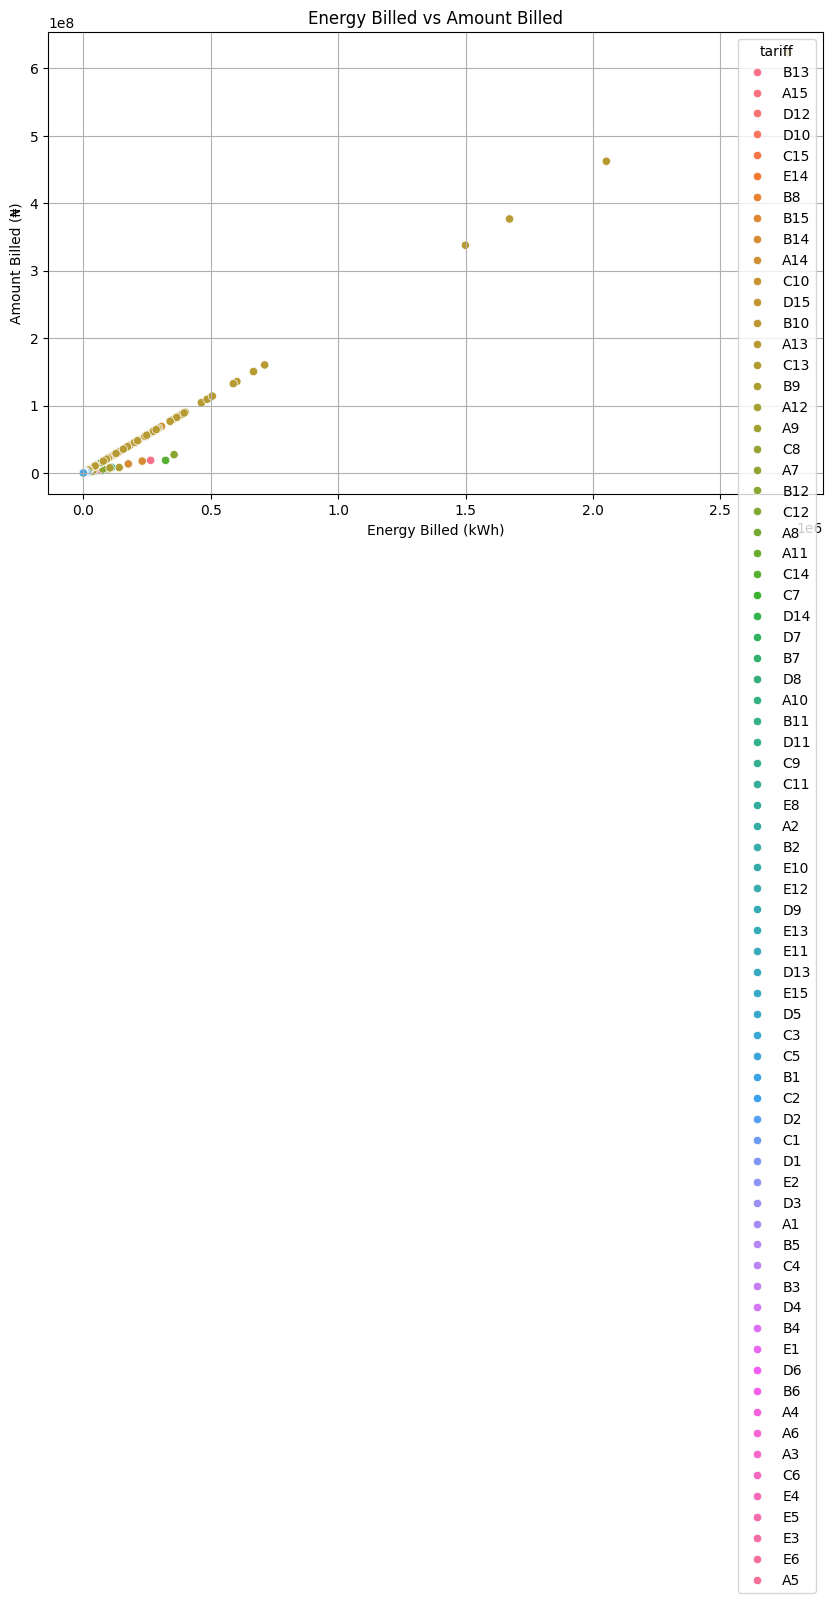

In [48]:
# Plot: Energy Billed vs Amount billed
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='consumption', y='bill_amount', hue='tariff')
plt.title("Energy Billed vs Amount Billed")
plt.xlabel("Energy Billed (kWh)")
plt.ylabel("Amount Billed (₦)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
avg = df['bill_amount'].mean()
above_avg = df[df['bill_amount'] > avg]

print(above_avg[['account_number', 'bill_amount']])

       account_number  bill_amount
0         KN659082472    238350.05
16       KN6885217017    125979.43
18       KN8977758757    261419.98
21       KN9613421611   6942963.56
22       KN3406140512     33264.53
...               ...          ...
452003   KN4247964705     83171.30
452008   KN5361145153     73689.50
452010   KN9459740387     33239.54
452024    KN259392168    172107.50
452051   KN1444824453     98643.08

[3197 rows x 2 columns]


In [50]:
df["adjustments_total"].sum()

np.float64(-1141837621.57)

In [51]:
df["adjustments_total"].min()

np.float64(-105531266.9)

In [52]:
df["adjustments_total"].value_counts()

adjustments_total
 0.00         451497
-19238.03         33
-17995.38         24
-28678.31         15
-15494.74         12
               ...  
-674834.29         1
-126592.54         1
-417862.07         1
-70973.09          1
-6258.78           1
Name: count, Length: 415, dtype: int64

In [53]:
df["previous_payments"].sum()

np.float64(9748250826.929998)

In [54]:
df["bill_amount"].sum()

np.float64(12668724803.499998)

In [55]:
df['bill_amount'].std()

np.float64(1653660.1029692627)

<Axes: >

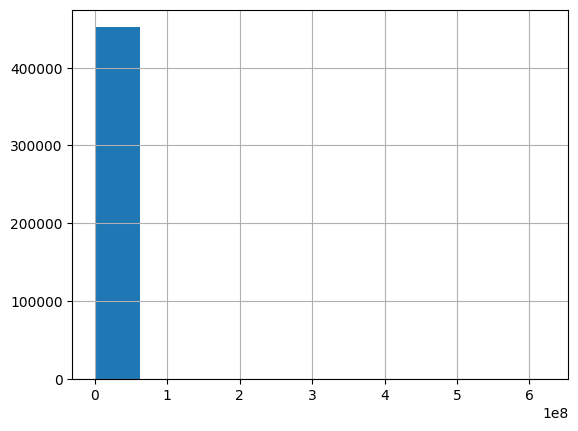

In [56]:
df['bill_amount'].hist()

In [57]:
top_balance = df.sort_values(
    by='closing_balance',
    ascending=False
)

top2 = top_balance[['account_number', 'consumption', 'bill_amount','previous_payments', 'closing_balance']]
top = top2.head(200)

top.to_csv(r"C:\Users\ibrahim.zimit\Desktop\top.csv", index=False)

In [58]:
df['payment_ratio'] = df['previous_payments'] / df['bill_amount']
df[['account_number', 'payment_ratio']]

,account_number,payment_ratio
0,KN659082472,0.000000
1,KN7056049034,inf
2,KN3200745355,inf
3,KN5445608646,inf
4,KN2527191691,inf
...,...,...
452053,KN8739999776,1.452581
452054,KN5611630739,0.000000
452055,KN9726639846,0.000000
452056,KN2869466086,0.000000


In [59]:
risk = df[df['previous_payments'] < df['bill_amount']]

risk[['account_number', 'bill_amount', 'previous_payments', 'closing_balance']]

,account_number,bill_amount,previous_payments,closing_balance
0,KN659082472,238350.05,0.00,238350.05
16,KN6885217017,125979.43,5828.09,120204.56
22,KN3406140512,33264.53,10000.00,23216.49
24,KN5270732663,1242732.08,0.00,1298576.08
25,KN7787468128,291201.25,0.00,736219.30
...,...,...,...,...
452050,KN6078300212,2753.72,0.00,8261.16
452051,KN1444824453,98643.08,0.00,189290.24
452054,KN5611630739,3579.64,0.00,44340.70
452055,KN9726639846,3579.64,0.00,65138.97


In [60]:
collection_rate = total_collected / total_billed * 100
print("Collection rate:", collection_rate, "%")

Collection rate: 76.94737219516239 %


In [61]:
worst = df.sort_values(
    by='closing_balance',
    ascending=False
)

worst[['account_number', 'closing_balance']].head(5)

,account_number,closing_balance
1318,KN9965211244,1.832037e+09
1617,KN6922056012,1.406728e+09
97,KN1827434346,1.154338e+09
1602,KN944040805,9.251295e+08
523,KN6226872253,6.363150e+08


In [62]:
df['payment_percent'] = (df['previous_payments'] / df['bill_amount']) * 100
df[['account_number', 'payment_percent']]

,account_number,payment_percent
0,KN659082472,0.000000
1,KN7056049034,inf
2,KN3200745355,inf
3,KN5445608646,inf
4,KN2527191691,inf
...,...,...
452053,KN8739999776,145.258051
452054,KN5611630739,0.000000
452055,KN9726639846,0.000000
452056,KN2869466086,0.000000


In [63]:
# Anomaly detection: High consumption but low bill
anomalies = df[(df['consumption'] > 0) & (df['bill_amount'] == 0)]
print(f"\nAnomalies Detected (High Consumption but Low Bill): {len(anomalies)} records")
print(anomalies[['account_number', 'consumption', 'bill_amount']])


Anomalies Detected (High Consumption but Low Bill): 0 records
Empty DataFrame
Columns: [account_number, consumption, bill_amount]
Index: []


In [64]:
df.to_excel(r"C:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\data\final.xlsx", index=False)

In [65]:
columns_to_extract = ["account_number",  "bill_amount", "consumption", "previous_payments", "closing_balance"]

result_df = pd.merge(
    df, df[columns_to_extract], on="account_number", how="left"
)

result_df

,account_number,type,final_reading,initial_reading,multiplier,consumption_x,tariff,rate,previous_closing_balance,previous_payments_x,...,closing_balance_x,period,bill_style,feeder,payment_ratio,payment_percent,bill_amount_y,consumption_y,previous_payments_y,closing_balance_y
0,KN659082472,MD,3118.0,0.0,1.0,3118.0,B13,71.11,0.00,0.00,...,238350.05,2024-12-01,read,11KV KEDCO,0.000000,0.000000,238350.05,3118.0,0.00,238350.05
1,KN7056049034,MD,1.0,1.0,1.0,0.0,A15,209.50,6551886.70,836632.25,...,5472678.01,2024-12-01,read,11KV KEDCO,inf,inf,0.00,0.0,836632.25,5472678.01
2,KN3200745355,MD,21367.0,21367.0,1.0,0.0,D12,47.58,155626.96,4736.36,...,149079.94,2024-12-01,read,11KV KEDCO,inf,inf,0.00,0.0,4736.36,149079.94
3,KN5445608646,MD,7500.0,7500.0,1.0,0.0,D10,47.58,151760.13,7263.09,...,142041.91,2024-12-01,read,11KV KEDCO,inf,inf,0.00,0.0,7263.09,142041.91
4,KN2527191691,MD,1.0,1.0,1.0,0.0,C15,49.51,1381231.01,6333.57,...,1374897.44,2024-12-01,read,11KV KEDCO,inf,inf,0.00,0.0,6333.57,1374897.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452071,KN8739999776,NMD,0.0,0.0,1.0,80.0,D2,32.02,5507.44,4000.00,...,4261.16,2024-12-01,estimated,11KV Garki,1.452581,145.258051,2753.72,80.0,4000.00,4261.16
452072,KN5611630739,NMD,0.0,0.0,1.0,70.0,C2,47.57,40761.06,0.00,...,44340.70,2024-12-01,estimated,11KV Garki,0.000000,0.000000,3579.64,70.0,0.00,44340.70
452073,KN9726639846,NMD,0.0,0.0,1.0,70.0,C2,47.57,61559.33,0.00,...,65138.97,2024-12-01,estimated,11KV Garki,0.000000,0.000000,3579.64,70.0,0.00,65138.97
452074,KN2869466086,NMD,0.0,0.0,1.0,132.0,C2,47.57,5264.01,0.00,...,12014.19,2024-12-01,direct,11KV Garki,0.000000,0.000000,6750.18,132.0,0.00,12014.19


In [66]:
result_df.to_excel(r"C:\Users\ibrahim.zimit\Desktop\billing-ar-analysis\result.xlsx", index=False)

In [68]:
##
# Replicating XLOOKUP for just the 'customer' column
result_df = pd.merge(
    df,
    df[["account_number", "consumption", "bill_amount"]],
    on="account_number",
    how="left",
)
##
result_df

,account_number,type,final_reading,initial_reading,multiplier,consumption_x,tariff,rate,previous_closing_balance,previous_payments,...,adjustments_total,bill_amount_x,closing_balance,period,bill_style,feeder,payment_ratio,payment_percent,consumption_y,bill_amount_y
0,KN659082472,MD,3118.0,0.0,1.0,3118.0,B13,71.11,0.00,0.00,...,0.00,238350.05,238350.05,2024-12-01,read,11KV KEDCO,0.000000,0.000000,3118.0,238350.05
1,KN7056049034,MD,1.0,1.0,1.0,0.0,A15,209.50,6551886.70,836632.25,...,-242576.44,0.00,5472678.01,2024-12-01,read,11KV KEDCO,inf,inf,0.0,0.00
2,KN3200745355,MD,21367.0,21367.0,1.0,0.0,D12,47.58,155626.96,4736.36,...,-1810.66,0.00,149079.94,2024-12-01,read,11KV KEDCO,inf,inf,0.0,0.00
3,KN5445608646,MD,7500.0,7500.0,1.0,0.0,D10,47.58,151760.13,7263.09,...,-2455.13,0.00,142041.91,2024-12-01,read,11KV KEDCO,inf,inf,0.0,0.00
4,KN2527191691,MD,1.0,1.0,1.0,0.0,C15,49.51,1381231.01,6333.57,...,0.00,0.00,1374897.44,2024-12-01,read,11KV KEDCO,inf,inf,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452071,KN8739999776,NMD,0.0,0.0,1.0,80.0,D2,32.02,5507.44,4000.00,...,0.00,2753.72,4261.16,2024-12-01,estimated,11KV Garki,1.452581,145.258051,80.0,2753.72
452072,KN5611630739,NMD,0.0,0.0,1.0,70.0,C2,47.57,40761.06,0.00,...,0.00,3579.64,44340.70,2024-12-01,estimated,11KV Garki,0.000000,0.000000,70.0,3579.64
452073,KN9726639846,NMD,0.0,0.0,1.0,70.0,C2,47.57,61559.33,0.00,...,0.00,3579.64,65138.97,2024-12-01,estimated,11KV Garki,0.000000,0.000000,70.0,3579.64
452074,KN2869466086,NMD,0.0,0.0,1.0,132.0,C2,47.57,5264.01,0.00,...,0.00,6750.18,12014.19,2024-12-01,direct,11KV Garki,0.000000,0.000000,132.0,6750.18
